In [ ]:
!pip install ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

In [ ]:
heart_disease = fetch_ucirepo(id=45)
X_raw = heart_disease.data.features  # Features
y_raw = heart_disease.data.targets   # Targets (column: 'num')

# metadata (optional print)
print(heart_disease.metadata)

# variable information (optional print)
print(heart_disease.variables)

# Combine into single dataframe for easier preprocessing (matching original code)
dataset = pd.concat([X_raw, y_raw], axis=1)

dataset = dataset.dropna()
dataset['num']=np.where(dataset['num']==0,-1,1)
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
dataset['num'].unique()

array([-1,  1])

In [ ]:
print(dataset['num'].value_counts())
dataset.head()

num
-1    160
 1    137
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,-1
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,-1
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,-1


In [ ]:
dataset['num'].value_counts(normalize=True)

,proportion
num,
-1,0.538721
1,0.461279


<Axes: ylabel='Frequency'>

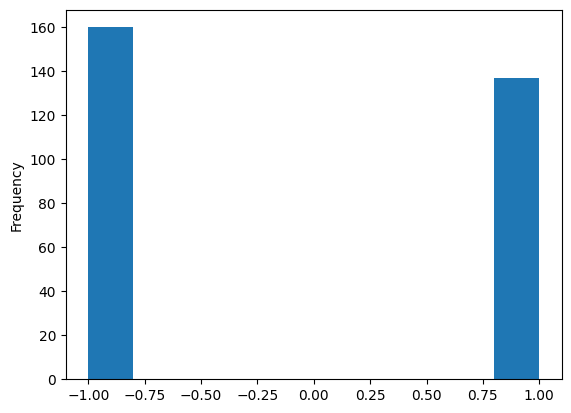

In [ ]:
dataset['num'].plot.hist()

In [ ]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,3.158249,0.964859,1.0,3.0,3.0,4.0,4.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=53)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
print(X_train[227])
sc=MinMaxScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)
xmin = sc.data_min_
xmax = sc.data_max_
print(X_train[227])
print(xmin)
print(xmax)


[ 55.    1.    4.  140.  217.    0.    0.  111.    1.    5.6   3.    0.
   7. ]
[0.54166667 1.         1.         0.43396226 0.32155477 0.
 0.         0.30534351 1.         1.         1.         0.
 1.        ]
[ 29.   0.   1.  94. 126.   0.   0.  71.   0.   0.   1.   0.   3.]
[ 77.    1.    4.  200.  409.    1.    2.  202.    1.    5.6   3.    3.
   7. ]


In [ ]:
xtrain_samples=X_train.shape[0]
xtest_samples=X_test.shape[0]
print(f'There are {xtrain_samples} samples for training and {xtest_samples} samples for testing')

There are 237 samples for training and 60 samples for testing


In [ ]:
from sklearn.svm import SVC
svc = SVC(
    kernel='sigmoid',
    gamma=1/X_train.shape[1],
    coef0=0,
    C=1.0
)
svc.fit(X_train,y_train)

SVC(coef0=0, gamma=0.07692307692307693, kernel='sigmoid')

In [ ]:
y_pred=svc.predict(X_test)

              precision    recall  f1-score   support

          -1       0.82      0.79      0.81        34
           1       0.74      0.77      0.75        26

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



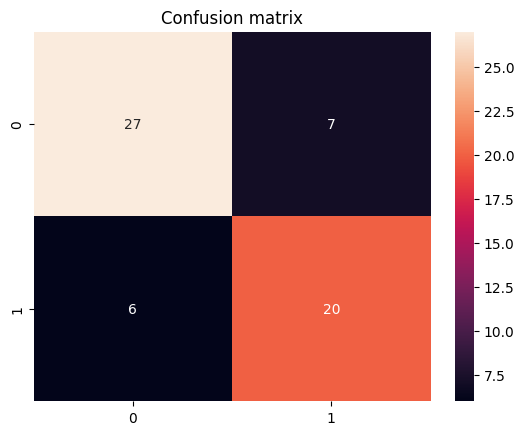

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d').set_title('Confusion matrix')
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.85      0.87      0.86       126
           1       0.85      0.83      0.84       111

    accuracy                           0.85       237
   macro avg       0.85      0.85      0.85       237
weighted avg       0.85      0.85      0.85       237



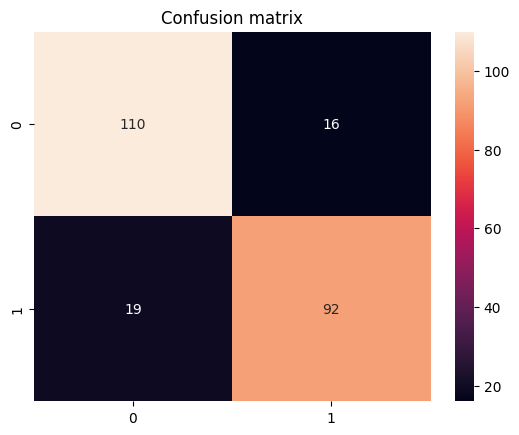

In [ ]:
y_pred_train=svc.predict(X_train)
cm=confusion_matrix(y_train,y_pred_train)
sns.heatmap(cm,annot=True,fmt='d').set_title('Confusion matrix')
print(classification_report(y_train,y_pred_train))

In [ ]:
svc.get_params()
print(svc.n_support_)

[70 68]


In [ ]:
decision_function=svc.decision_function(X_test)
print(decision_function)

[ 0.72878211  0.35775815 -0.83674586  0.90405926  0.07869036  1.14965979
 -1.41198999 -1.33478061 -1.29455109 -0.45874264  1.32673292  1.35643501
 -0.0092691   1.79071197  1.73631516 -0.70061049  0.72835464  1.14432683
 -0.35477137 -1.73128487  0.7334158  -1.57107924 -0.57101216 -0.15426226
  0.814824   -0.28275602  0.73440583 -1.27656942 -1.55390029 -0.78194142
  0.07235766 -1.04270369  0.16602838  0.31046948 -1.18544487 -0.84088489
 -0.98427842  1.41509376 -0.46557358 -0.36401673 -0.58648272 -1.67437505
 -0.21394522  0.42126887 -0.56746697 -1.37949444 -0.9890108  -0.95318131
 -0.58484577  0.64539964  0.29335917  0.33980394 -1.18916599  1.11746897
  0.65482606  0.19063723 -1.63646872 -0.57079312  1.3092238   0.58698925]


In [ ]:
print("svc.gamma: ",svc.gamma)
sv=open("support_vectors_sigmoid_heart.txt","w")
dual_coeff=open("dual_coeff_sigmoid_heart.txt","w")
intercept=open("intercept_sigmoid_heart.txt","w")
x_min="xmin_sigmoid_heart.txt"
x_max="xmax_sigmoid_heart.txt"
np.savetxt(sv,svc.support_vectors_)
np.savetxt(dual_coeff,svc.dual_coef_,delimiter=' ')
np.savetxt(intercept,svc.intercept_,delimiter=' ')
np.savetxt(x_min,xmin,delimiter=' ')
np.savetxt(x_max,xmax,delimiter=' ')

sv.close()
dual_coeff.close()
intercept.close()

svc.gamma:  0.07692307692307693


In [ ]:
decision_value = svc.decision_function([X_train[227]])
print(decision_value)
print(y_train[227])

[1.45229466]
1


In [ ]:
print("Support vectors shape:", svc.support_vectors_.shape)
print("Dual coef shape:", svc.dual_coef_.shape)

Support vectors shape: (138, 13)
Dual coef shape: (1, 138)


In [ ]:
print(svc.coef0)

0


In [ ]:
from sklearn.metrics import recall_score,precision_score,f1_score
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.7407407407407407
0.7692307692307693
0.7547169811320755
